In [3]:
# ============================================================
# TASK 1 : House Price Predictor using Linear Regression
# Dataset : California Housing Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# ============================================================
# LOAD THE CALIFORNIA HOUSING DATASET
# ============================================================

data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

✅ Dataset loaded successfully!
Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# ============================================================
# BASIC DATA EXPLORATION
# ============================================================

print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Data Types & Info ===")
print(df.info())

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Shape ===
Rows: 20640, Columns: 9

=== Data Types & Info ===
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

=== Statistical Summary ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# ============================================================
# CHECK FOR MISSING VALUES
# ============================================================

print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing)

print(f"\nTotal missing values: {missing.sum()}")
print("\n✅ No missing values — dataset is clean and ready!")

=== Missing Values ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0

✅ No missing values — dataset is clean and ready!


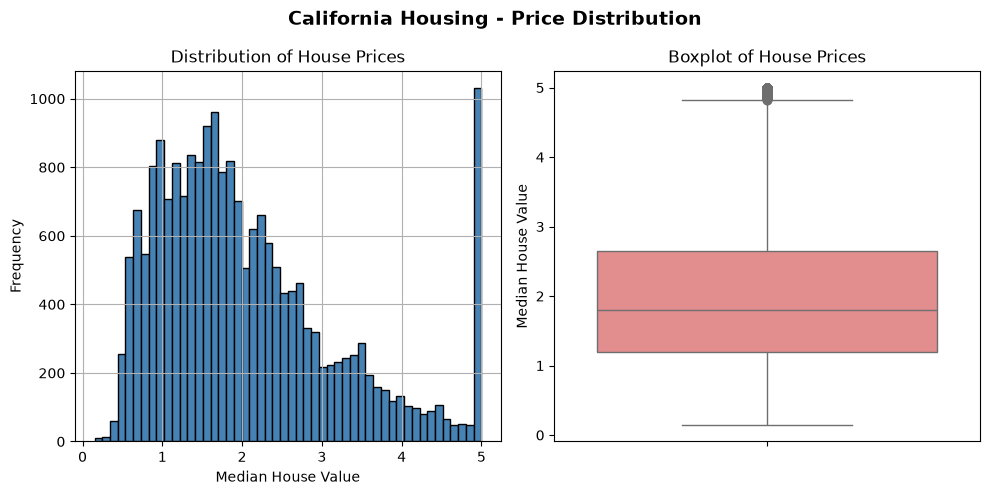

✅ Plot saved!


In [8]:
# ============================================================
# VISUALIZING THE TARGET VARIABLE (HOUSE PRICES)
# ============================================================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['MedHouseVal'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['MedHouseVal'], color='lightcoral')
plt.title('Boxplot of House Prices')
plt.ylabel('Median House Value')

plt.suptitle('California Housing - Price Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved!")

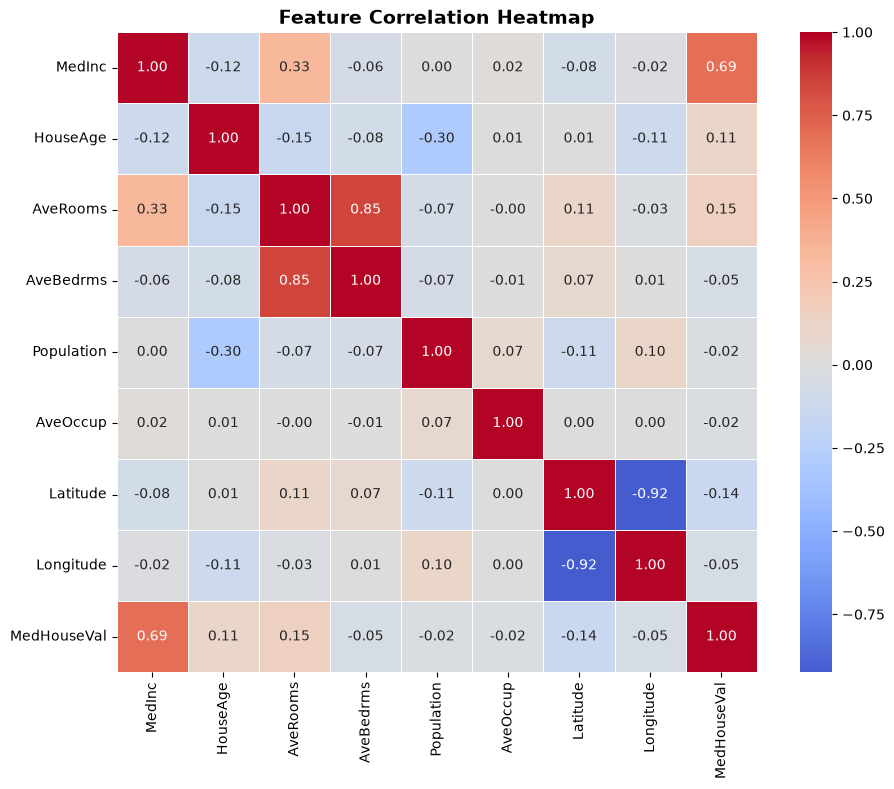

✅ Heatmap saved!

=== Correlation with House Price ===
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [9]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 8))
correlation = df.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Heatmap saved!")
print("\n=== Correlation with House Price ===")
print(correlation['MedHouseVal'].sort_values(ascending=False))

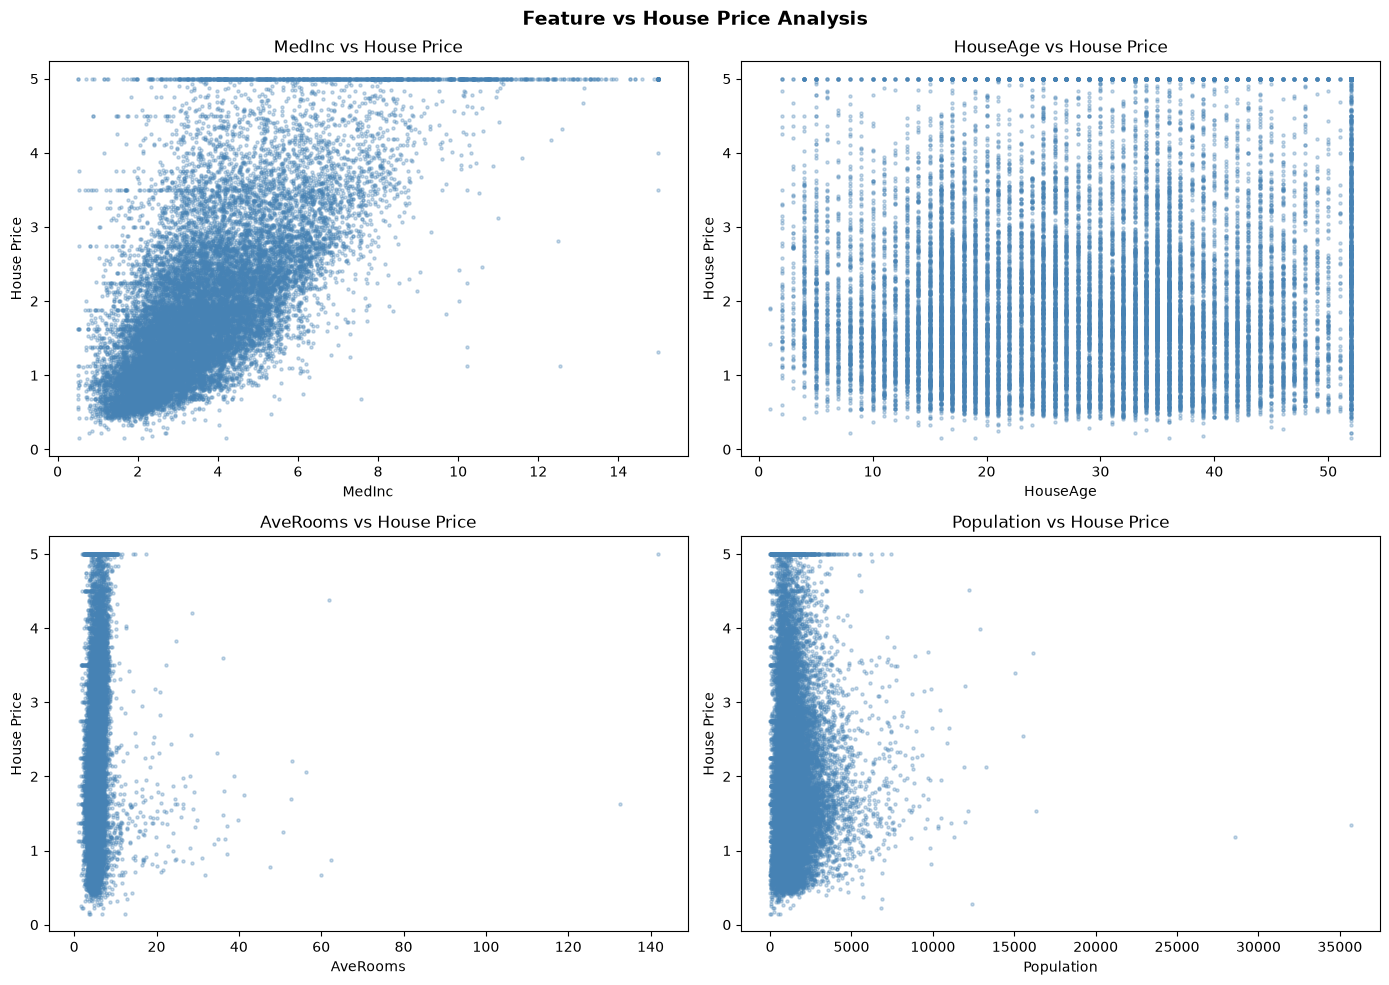

✅ Scatter plots saved!


In [10]:
# ============================================================
# FEATURE VS HOUSE PRICE SCATTER PLOTS
# ============================================================

features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']

plt.figure(figsize=(14, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    plt.scatter(df[feature], df['MedHouseVal'], alpha=0.3, color='steelblue', s=5)
    plt.xlabel(feature)
    plt.ylabel('House Price')
    plt.title(f'{feature} vs House Price')

plt.suptitle('Feature vs House Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Scatter plots saved!")

In [11]:
# ============================================================
# FEATURE SELECTION & TRAIN/TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal')  # features (inputs)
y = df['MedHouseVal']               # target (output)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split successfully!")
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"\nFeatures used    : {list(X.columns)}")

✅ Data split successfully!

Training samples : 16512
Testing samples  : 4128

Features used    : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [12]:
# ============================================================
# TRAIN THE LINEAR REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("✅ Model trained successfully!")
print("\n=== Model Coefficients ===")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:15s} : {coef:.4f}")

print(f"\nIntercept: {model.intercept_:.4f}")

✅ Model trained successfully!

=== Model Coefficients ===
MedInc          : 0.4487
HouseAge        : 0.0097
AveRooms        : -0.1233
AveBedrms       : 0.7831
Population      : -0.0000
AveOccup        : -0.0035
Latitude        : -0.4198
Longitude       : -0.4337

Intercept: -37.0233


In [13]:
# ============================================================
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE  (Mean Absolute Error) : {mae:.4f}")
print(f"  RMSE (Root Mean Sq. Error) : {rmse:.4f}")
print(f"  R²   (R-Squared Score)     : {r2:.4f}")
print("=" * 40)

if r2 >= 0.6:
    print("\n✅ Model is performing reasonably well!")
else:
    print("\n⚠️ Model needs improvement.")

       MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error) : 0.5332
  RMSE (Root Mean Sq. Error) : 0.7456
  R²   (R-Squared Score)     : 0.5758

⚠️ Model needs improvement.


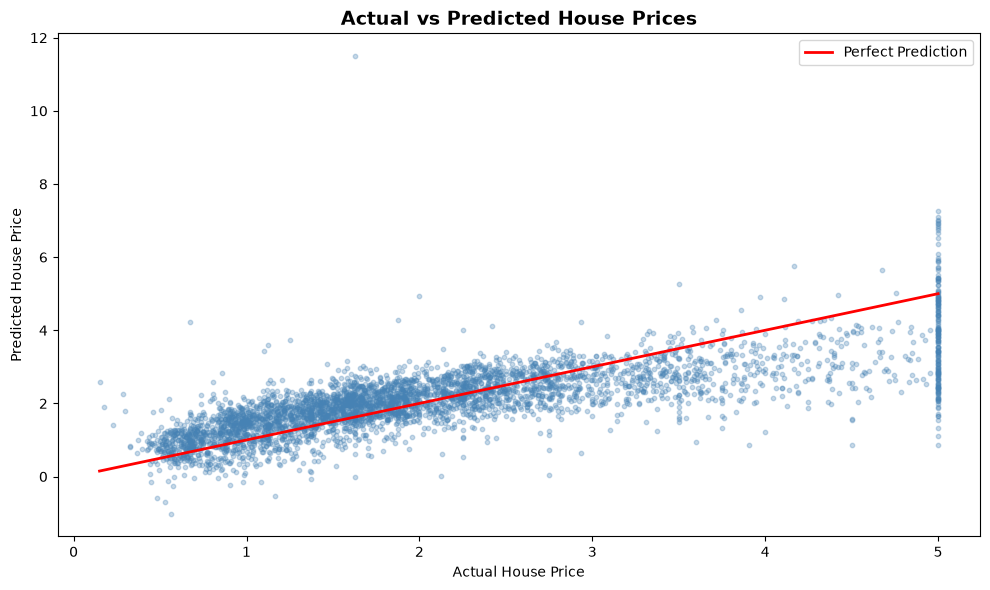

✅ Plot saved!


In [14]:
# ============================================================
# ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved!")

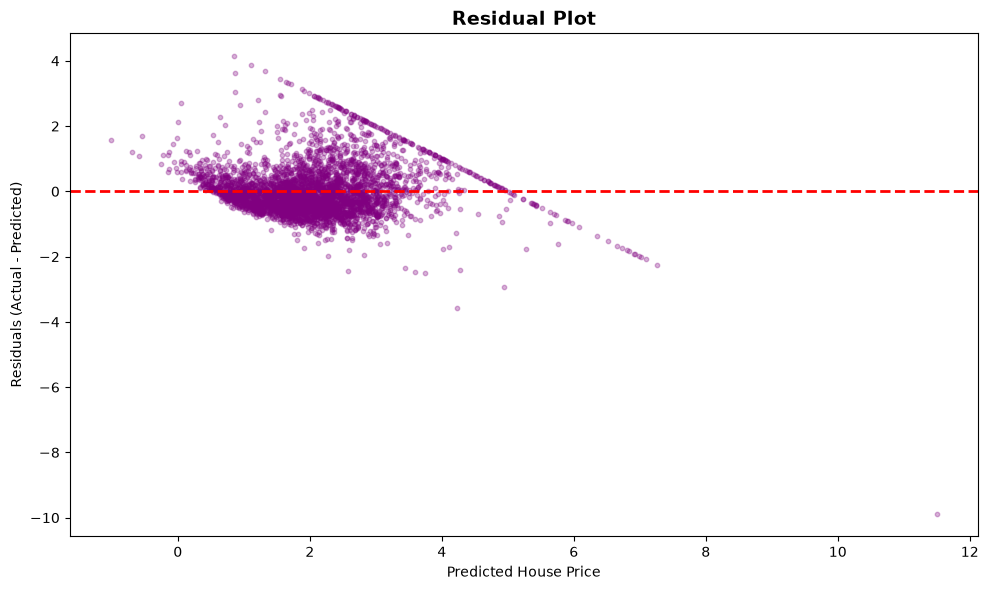

✅ Residual plot saved!

Mean of residuals: 0.0035
Std of residuals : 0.7457


In [15]:
# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.3, color='purple', s=10)
plt.axhline(y=0, color='red', linewidth=2, linestyle='--')

plt.xlabel('Predicted House Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Residual plot saved!")
print(f"\nMean of residuals: {residuals.mean():.4f}")
print(f"Std of residuals : {residuals.std():.4f}")

In [16]:
# ============================================================
# SAVE THE TRAINED MODEL
# ============================================================

import pickle

with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Model saved as 'linear_regression_model.pkl'")

✅ Model saved as 'linear_regression_model.pkl'


In [17]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 50)
print("        HOUSE PRICE PREDICTOR - SUMMARY")
print("=" * 50)
print(f"\n📦 Dataset     : California Housing")
print(f"📊 Total Rows  : {df.shape[0]}")
print(f"🔢 Features    : {X.shape[1]}")
print(f"🏋️  Train Size  : {X_train.shape[0]}")
print(f"🧪 Test Size   : {X_test.shape[0]}")
print("\n--- Model Performance ---")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("\n--- Improvements Suggested ---")
print("  • Feature Scaling (StandardScaler)")
print("  • Try Ridge / Lasso Regression")
print("  • Add Polynomial Features")
print("  • Try Random Forest Regressor")
print("=" * 50)
print("\n✅ Task 1 Complete!")

        HOUSE PRICE PREDICTOR - SUMMARY

📦 Dataset     : California Housing
📊 Total Rows  : 20640
🔢 Features    : 8
🏋️  Train Size  : 16512
🧪 Test Size   : 4128

--- Model Performance ---
  MAE  : 0.5332
  RMSE : 0.7456
  R²   : 0.5758

--- Improvements Suggested ---
  • Feature Scaling (StandardScaler)
  • Try Ridge / Lasso Regression
  • Add Polynomial Features
  • Try Random Forest Regressor

✅ Task 1 Complete!
